In [ ]:
from google.colab import files
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Upload the file
uploaded = files.upload()

Saving DataMentalHelth.csv to DataMentalHelth (3).csv


In [ ]:
Data = pd.read_csv("DataMentalHelth.csv")

In [ ]:
Data.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
Data.tail()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN
1258,2016-02-01 23:04:31,25,Male,United States,IL,No,Yes,Yes,Sometimes,26-100,...,Don't know,Maybe,No,Some of them,No,No,No,Don't know,No,NaN


In [ ]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [ ]:
Data.describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [ ]:
Data.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [ ]:
copydata = Data.copy()

In [ ]:
copydata.shape

(1259, 27)

In [ ]:
copydata = copydata.drop(['Timestamp', 'comments', 'state' , 'Country' , 'leave' , 'obs_consequence' , 'phys_health_interview','mental_vs_physical'] , axis=1)

In [ ]:
copydata.shape

(1259, 19)

In [ ]:
copydata.isnull().sum()

,0
Age,0
Gender,0
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0
remote_work,0
tech_company,0
benefits,0


In [ ]:
missing_values = copydata.isnull().sum()
missing_percentage = (missing_values / len(copydata)) * 100
missing_report = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})

In [ ]:
print(" Missing Values Report:\n", missing_report[missing_report['Missing Values'] > 0])

 Missing Values Report:
                 Missing Values  Percentage
self_employed               18    1.429706
work_interfere             264   20.969023


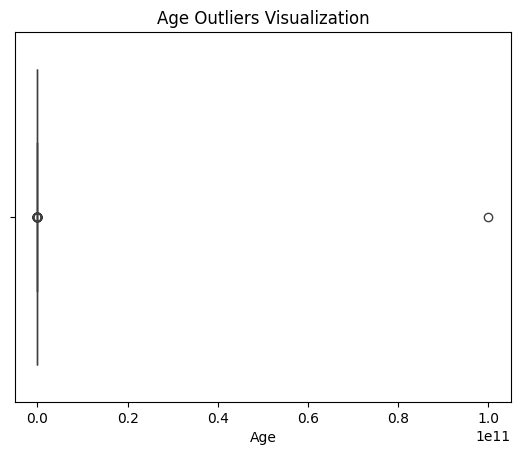

In [ ]:
sns.boxplot(x=copydata['Age'])
plt.title('Age Outliers Visualization')
plt.show()

In [ ]:
copydata['Age'] = pd.to_numeric(copydata['Age'], errors='coerce')
Q1 = copydata['Age'].quantile(0.25)
Q3 = copydata['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [ ]:
outliers_count = copydata[(copydata['Age'] < lower_limit) | (copydata['Age'] > upper_limit)].shape[0]

In [ ]:
copydata = copydata[(copydata['Age'] >= lower_limit) & (copydata['Age'] <= upper_limit)]


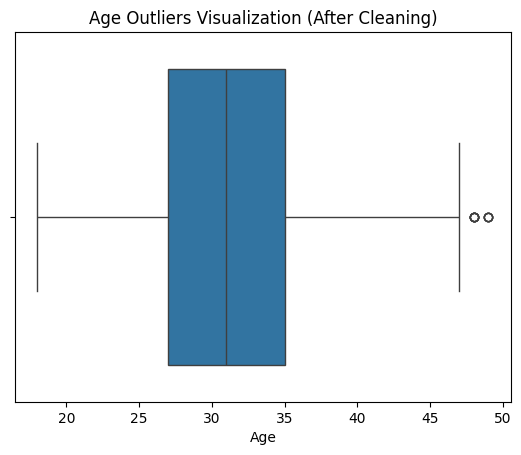

In [ ]:
sns.boxplot(x=copydata['Age'])
plt.title('Age Outliers Visualization (After Cleaning)')
plt.show()

In [ ]:
print(f"Age: {outliers_count}")

Age: 40


In [ ]:
num_cols = copydata.select_dtypes(include=['number']).columns
cat_cols = copydata.select_dtypes(include=['object', 'category', 'bool']).columns

for c in num_cols:
    copydata[c] = copydata[c].fillna(copydata[c].mean())

for c in cat_cols:
    copydata[c] = copydata[c].fillna(copydata[c].mode().iloc[0])

In [ ]:
copydata.isnull().sum()

,0
Age,0
Gender,0
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0
remote_work,0
tech_company,0
benefits,0


In [ ]:
copydata.isnull().sum().sort_values(ascending=False)

,0
Age,0
Gender,0
self_employed,0
family_history,0
treatment,0
work_interfere,0
no_employees,0
remote_work,0
tech_company,0
benefits,0


In [ ]:
from sklearn.preprocessing import LabelEncoder


cat_cols = copydata.select_dtypes(include=['object', 'category', 'bool']).columns

le = LabelEncoder()
for col in cat_cols:
    copydata[col] = le.fit_transform(copydata[col].astype(str))

copydata.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview
0,37,8,0,0,1,1,4,0,1,2,1,1,2,2,1,1,1,2,1
1,44,14,0,0,0,2,5,0,0,0,0,0,0,0,0,1,0,0,1
2,32,18,0,0,0,2,4,0,1,1,0,1,1,0,1,1,2,2,2
3,31,18,0,1,1,1,2,0,1,1,2,1,1,1,2,2,1,0,0
4,31,18,0,0,0,0,1,1,1,2,0,0,0,0,1,1,1,2,2


In [ ]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


copydata['Age'] = scaler.fit_transform(copydata[['Age']])


print(copydata['Age'].head())


0    0.881705
1    1.997468
2    0.084732
3   -0.074663
4   -0.074663
Name: Age, dtype: float64


In [ ]:
copydata['Age'].describe()


,Age
count,1.219000e+03
mean,1.398936e-16
std,1.000410e+00
min,-2.146794e+00
25%,-7.122419e-01
50%,-7.466314e-02
75%,5.629156e-01
max,2.794441e+00


In [ ]:
copydata.dtypes


,0
Age,float64
Gender,int64
self_employed,int64
family_history,int64
treatment,int64
work_interfere,int64
no_employees,int64
remote_work,int64
tech_company,int64
benefits,int64


# Step 2 - Models Training

In [ ]:

X = copydata.drop(columns=['treatment'])
y = copydata['treatment']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 3) Evaluation function

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, model):
    """
    This function trains the model and prints
    the main evaluation metrics.
    """

    # Fit the model on the training data
    model.fit(X_train, y_train)

    # Predict the labels for the test set
    y_pred = model.predict(X_test)

    # Calculate evaluation metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    # Print results in a clear format
    print("\n===================================")
    print(f"{name} - Evaluation Results")
    print("===================================")
    print(f"Accuracy   : {acc:.3f}")
    print(f"Precision  : {prec:.3f}")
    print(f"Recall     : {rec:.3f}")
    print(f"F1-score   : {f1:.3f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Return metrics in a dictionary (optional – for comparison table)
    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1
    }


#  Logistic Regression

In [ ]:

from sklearn.linear_model import LogisticRegression

# Step 1: Create the model
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')

# Step 2: Train + Evaluate
results_lr = evaluate_model("Logistic Regression", log_reg)

log_reg


Logistic Regression - Evaluation Results
Accuracy   : 0.680
Precision  : 0.710
Recall     : 0.618
F1-score   : 0.661

Confusion Matrix:
[[90 31]
 [47 76]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.74      0.70       121
           1       0.71      0.62      0.66       123

    accuracy                           0.68       244
   macro avg       0.68      0.68      0.68       244
weighted avg       0.68      0.68      0.68       244



LogisticRegression(max_iter=1000)

Logistic Regression - Confusion Matrix:
[[90 31]
 [47 76]]


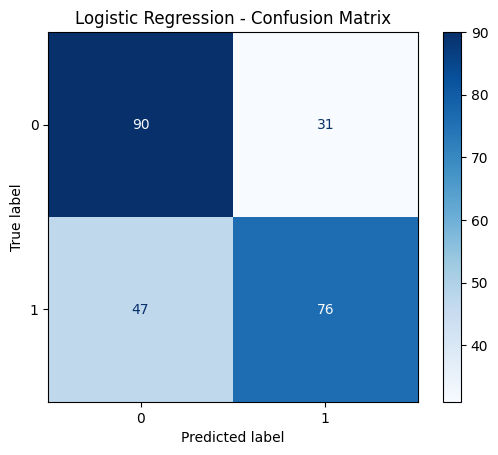

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, solver='lbfgs')
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Logistic Regression - Confusion Matrix:")
print(cm_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()



# Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Step 1: Create the model
dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    class_weight='balanced'
)

# Step 2: Train + Evaluate
results_dt = evaluate_model("Decision Tree", dt)


dt


Decision Tree - Evaluation Results
Accuracy   : 0.635
Precision  : 0.657
Recall     : 0.577
F1-score   : 0.615

Confusion Matrix:
[[84 37]
 [52 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.69      0.65       121
           1       0.66      0.58      0.61       123

    accuracy                           0.64       244
   macro avg       0.64      0.64      0.63       244
weighted avg       0.64      0.64      0.63       244



DecisionTreeClassifier(class_weight='balanced', random_state=42)

Decision Tree - Confusion Matrix:
[[85 36]
 [51 72]]


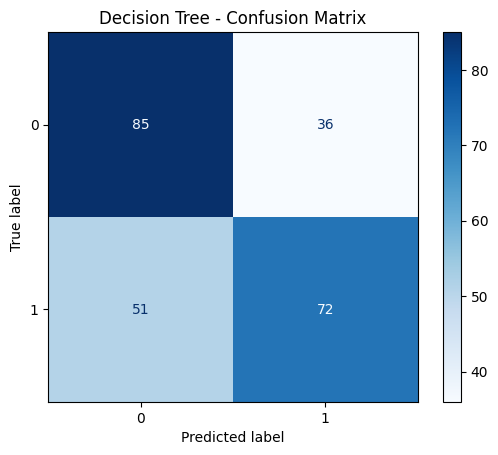

In [ ]:
# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Decision Tree - Confusion Matrix:")
print(cm_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt)
disp.plot(cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.show()


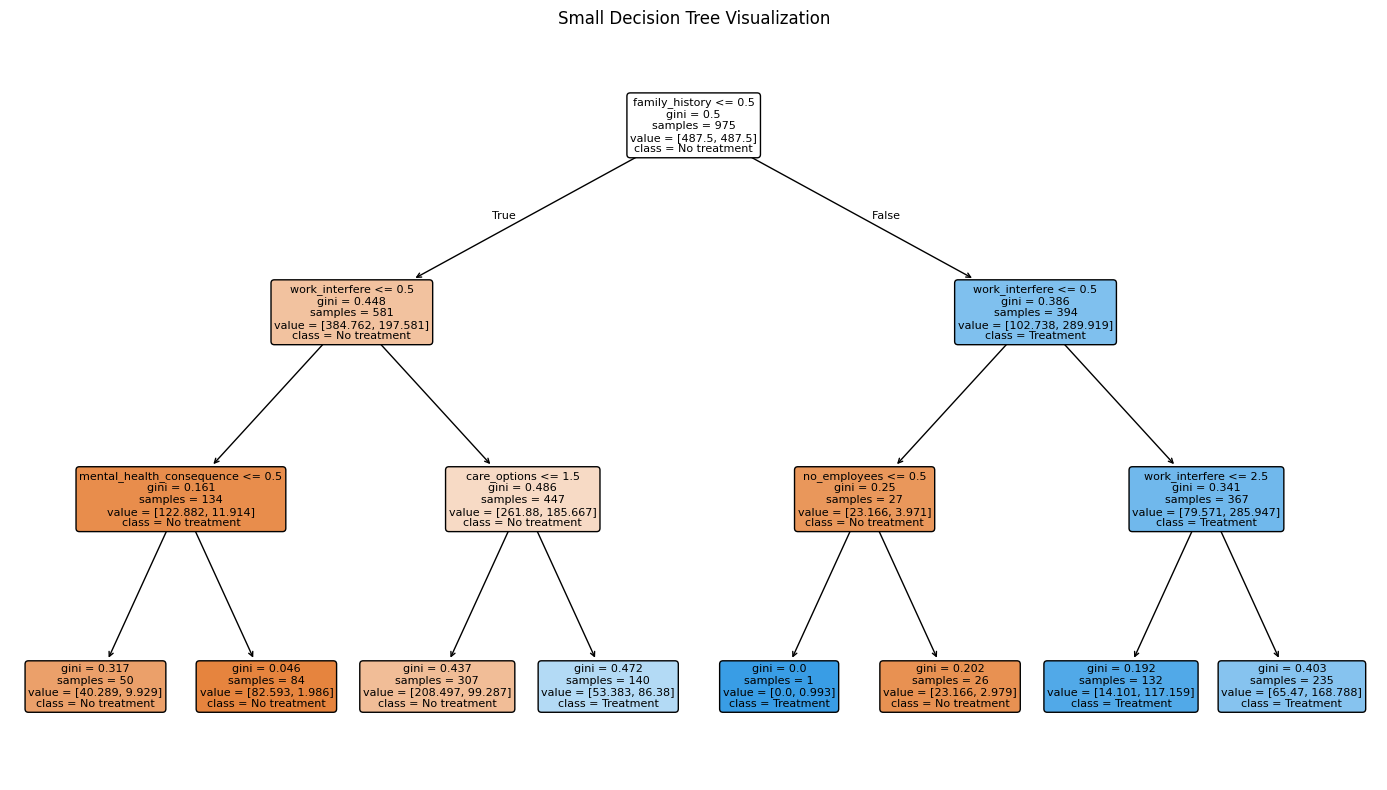

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

small_dt = DecisionTreeClassifier(
    criterion="gini",
    random_state=42,
    class_weight='balanced',
    max_depth=3
)

small_dt.fit(X_train, y_train)

plt.figure(figsize=(14, 8))

plot_tree(
    small_dt,
    feature_names=X_train.columns,
    class_names=['No treatment', 'Treatment'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Small Decision Tree Visualization")
plt.tight_layout()
plt.savefig("small_decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()


# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Create the model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

# Step 2: Train + Evaluate the model
results_rf = evaluate_model("Random Forest", rf)

rf


Random Forest - Evaluation Results
Accuracy   : 0.754
Precision  : 0.789
Recall     : 0.699
F1-score   : 0.741

Confusion Matrix:
[[98 23]
 [37 86]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.81      0.77       121
           1       0.79      0.70      0.74       123

    accuracy                           0.75       244
   macro avg       0.76      0.75      0.75       244
weighted avg       0.76      0.75      0.75       244



RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Random Forest - Confusion Matrix:
[[98 23]
 [37 86]]


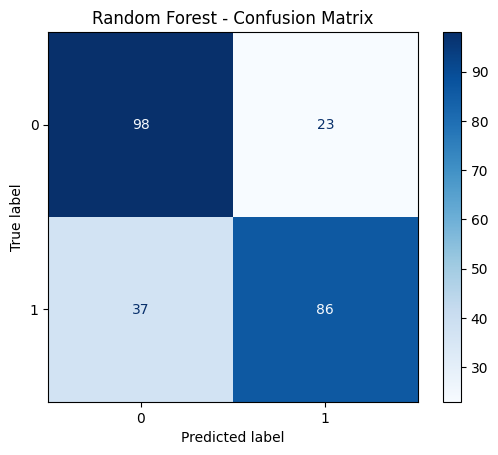

In [ ]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest - Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()


# Support Vector Machine (SVM)

In [ ]:

from sklearn.svm import SVC

# Step 1: Create the model
svm = SVC(
    kernel='rbf',          # RBF kernel (default and best for non-linear data)
    probability=True,      # allow predict_proba
    random_state=42
)

# Step 2: Train + Evaluate
results_svm = evaluate_model("Support Vector Machine", svm)

svm


Support Vector Machine - Evaluation Results
Accuracy   : 0.652
Precision  : 0.683
Recall     : 0.577
F1-score   : 0.626

Confusion Matrix:
[[88 33]
 [52 71]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.73      0.67       121
           1       0.68      0.58      0.63       123

    accuracy                           0.65       244
   macro avg       0.66      0.65      0.65       244
weighted avg       0.66      0.65      0.65       244



SVC(probability=True, random_state=42)

SVM - Confusion Matrix:
[[88 33]
 [52 71]]


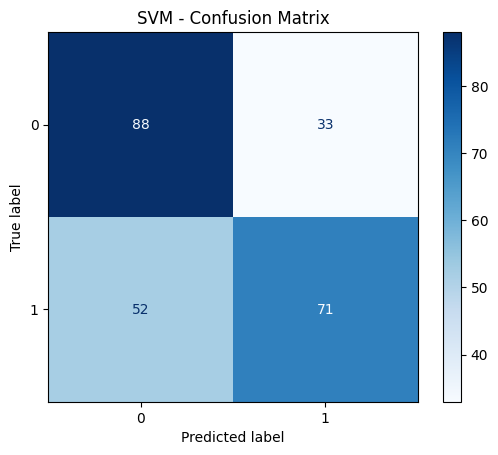

In [ ]:
# SVM
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)

cm_svm = confusion_matrix(y_test, y_pred_svm)
print("SVM - Confusion Matrix:")
print(cm_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot(cmap="Blues")
plt.title("SVM - Confusion Matrix")
plt.show()


#Compare Models Performance

In [ ]:
import pandas as pd

# Create a DataFrame from the results of all models
results_df = pd.DataFrame([
    results_lr,
    results_dt,
    results_rf,
    results_svm
])

# Sort models by F1-score (best at top)
results_df = results_df.sort_values(by='F1', ascending=False)

# Show the comparison table
results_df


,Model,Accuracy,Precision,Recall,F1
2,Random Forest,0.754098,0.788991,0.699187,0.741379
0,Logistic Regression,0.680328,0.710280,0.617886,0.660870
3,Support Vector Machine,0.651639,0.682692,0.577236,0.625551
1,Decision Tree,0.635246,0.657407,0.577236,0.614719
